# SOAL 04 — Optimasi Perbandingan Model dan Analisis Eksperimen
**UAS Pembelajaran Mesin — Sub-CPMK 81.3 & 101.2 (Bobot 25%)**

Universitas Dian Nuswantoro | Topik: Optimasi Teknik Machine Learning dalam Klasifikasi Tingkat Obesitas
Dataset: *Estimation of Obesity Levels Based on Eating Habits and Physical Condition* (2111 baris, target `NObeyesdad`, 7 kelas)

**Strategi optimasi yang diuji (≥3 sesuai instruksi soal):**
1. Hyperparameter tuning (GridSearchCV, scoring = macro-F1) untuk KNN, Naive Bayes, SVM (model wajib)
2. Stratified k-fold cross-validation untuk menguji stabilitas model
3. Feature selection berbasis feature importance (ExtraTrees)
4. Pemeriksaan class imbalance handling (class_weight) sebagai analisis sensitivitas
5. Perbandingan menyeluruh terhadap 11 model (baseline vs optimized, termasuk model pembanding di luar yang wajib)

**Output:** tabel eksperimen komparatif, grafik performa, error analysis, dan penentuan model terbaik.

In [1]:
import os, sys, time, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = os.path.abspath("..")
SRC_DIR = os.path.join(BASE_DIR, "src")
MODELS_DIR = os.path.join(BASE_DIR, "models")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
DATA_PATH = os.path.join(BASE_DIR, "data", "ObesityDataSet_raw_and_data_sinthetic.csv")
sys.path.insert(0, SRC_DIR)

from preprocessing import run_preprocessing

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              balanced_accuracy_score, confusion_matrix, classification_report)

RANDOM_SEED = 42
ORDER_TARGET = ["Insufficient_Weight","Normal_Weight","Overweight_Level_I","Overweight_Level_II",
                "Obesity_Type_I","Obesity_Type_II","Obesity_Type_III"]

sns.set_style("whitegrid")
print("Setup selesai.")

Setup selesai.


In [2]:
X, y, scaler, oe = run_preprocessing(DATA_PATH, models_dir=MODELS_DIR,
                                      clean_data_path=os.path.join(BASE_DIR, "data", "obesity_cleaned_data.csv"))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)
joblib.dump(scaler, os.path.join(MODELS_DIR, "scaler.joblib"))

print("Train:", X_train_sc.shape, " Test:", X_test_sc.shape)
print("\nDistribusi target (train):")
print(y_train.value_counts(normalize=True).sort_index().rename(index=lambda i: ORDER_TARGET[i]))

[Load] Dataset dimuat dari: /home/claude/project/ml-uts-A11.2024.15791-Anza_Ali_S/data/ObesityDataSet_raw_and_data_sinthetic.csv
       Dimensi awal : 2111 baris x 17 kolom
       Missing value: 0
       Duplikat     : 24
[1] Hapus 24 duplikat → 2087 baris tersisa
[2] Binary encoding: Gender, family_history, FAVC, SMOKE, SCC
[3] Ordinal encoding: CAEC & CALC (no=0, Sometimes=1, Frequently=2, Always=3)
    OrdinalEncoder disimpan ke: /home/claude/project/ml-uts-A11.2024.15791-Anza_Ali_S/models/ordinal_encoder.joblib
[4] One-hot MTRANS → 5 kolom baru: ['MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']
[5] Winsorizing outlier pada: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
[6] Encoding target: Insufficient_Weight=0 … Obesity_Type_III=6

✓ Data bersih disimpan ke: /home/claude/project/ml-uts-A11.2024.15791-Anza_Ali_S/data/obesity_cleaned_data.csv

  Shape akhir : X=(2087, 20), y=(2087,)

TABEL RINGKASAN BEFORE/A

## Strategi 1 — Hyperparameter Tuning (GridSearchCV)
Model wajib (KNN, Naive Bayes, SVM) dibandingkan pada dua tahap: **baseline** (parameter manual, sama seperti SOAL 03) vs **optimized**
(hasil `GridSearchCV` dengan `scoring="f1_macro"` dan `StratifiedKFold(5)`), agar perbandingan tidak hanya berdasarkan akurasi semata.

In [3]:
BASELINE_PARAMS = {
    "KNN":        {"n_neighbors": 7, "metric": "euclidean"},
    "NaiveBayes": {"var_smoothing": 1e-9},
    "SVM":        {"kernel": "rbf", "C": 1.0, "gamma": "scale"},
}

PARAM_GRIDS = {
    "KNN": {"n_neighbors": [3,5,7,9,11,15], "weights": ["uniform","distance"],
            "metric": ["euclidean","manhattan","minkowski"]},
    "NaiveBayes": {"var_smoothing": np.logspace(-12, -1, 12)},
    "SVM": {"C": [0.1,1,10,100], "gamma": ["scale","auto",0.01,0.1], "kernel": ["rbf","linear"]},
}

ESTIMATORS = {
    "KNN": KNeighborsClassifier(),
    "NaiveBayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=RANDOM_SEED),
}

def evaluate(model, X_te, y_te, train_ms):
    y_pred = model.predict(X_te)
    return {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision_weighted": precision_score(y_te, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_te, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_te, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_te, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_te, y_pred),
        "train_ms": train_ms, "y_pred": y_pred,
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
all_results, fitted_models, error_rows = [], {}, []

for name in ["KNN", "NaiveBayes", "SVM"]:
    print("="*70, f"\nMODEL: {name}")
    # Baseline
    base_model = ESTIMATORS[name].__class__(**BASELINE_PARAMS[name]) if name != "SVM" \
                 else SVC(probability=True, random_state=RANDOM_SEED, **BASELINE_PARAMS[name])
    t0 = time.time(); base_model.fit(X_train_sc, y_train); t_base = (time.time()-t0)*1000
    base = evaluate(base_model, X_test_sc, y_test, t_base)
    print(f"  [Baseline]  Acc={base['accuracy']:.4f} F1m={base['f1_macro']:.4f} params={BASELINE_PARAMS[name]}")

    # Optimized
    grid = GridSearchCV(ESTIMATORS[name], PARAM_GRIDS[name], scoring="f1_macro", cv=cv, n_jobs=-1, refit=True)
    t0 = time.time(); grid.fit(X_train_sc, y_train); t_opt = (time.time()-t0)*1000
    opt = evaluate(grid.best_estimator_, X_test_sc, y_test, t_opt)
    print(f"  [Optimized] Acc={opt['accuracy']:.4f} F1m={opt['f1_macro']:.4f} best_params={grid.best_params_} (CV F1m={grid.best_score_:.4f})")
    print(f"  Delta F1-macro = {opt['f1_macro']-base['f1_macro']:+.4f}")

    for stage, res, params in [("baseline", base, BASELINE_PARAMS[name]), ("optimized", opt, grid.best_params_)]:
        all_results.append({"model": name, "stage": stage, "params": json.dumps(params, default=str),
                             **{k: res[k] for k in ["accuracy","precision_weighted","recall_weighted","f1_weighted","f1_macro","balanced_accuracy","train_ms"]}})

    fitted_models[name] = grid.best_estimator_
    joblib.dump(grid.best_estimator_, os.path.join(MODELS_DIR, f"{name.lower()}_optimized.joblib"))

    wrong = np.where(y_test.values != opt["y_pred"])[0]
    for i in wrong[:10]:
        error_rows.append({"model": name, "row_index": int(X_test.index[i]),
                            "y_true": ORDER_TARGET[y_test.values[i]], "y_pred": ORDER_TARGET[opt["y_pred"][i]]})

results_df = pd.DataFrame(all_results)
results_df

MODEL: KNN
  [Baseline]  Acc=0.8062 F1m=0.7942 params={'n_neighbors': 7, 'metric': 'euclidean'}


  [Optimized] Acc=0.8636 F1m=0.8574 best_params={'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'} (CV F1m=0.8464)
  Delta F1-macro = +0.0632
MODEL: NaiveBayes
  [Baseline]  Acc=0.5287 F1m=0.4305 params={'var_smoothing': 1e-09}


  [Optimized] Acc=0.5766 F1m=0.5294 best_params={'var_smoothing': np.float64(0.1)} (CV F1m=0.5218)
  Delta F1-macro = +0.0989
MODEL: SVM


  [Baseline]  Acc=0.8565 F1m=0.8520 params={'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}


  [Optimized] Acc=0.9617 F1m=0.9615 best_params={'C': 10, 'gamma': 'scale', 'kernel': 'linear'} (CV F1m=0.9530)
  Delta F1-macro = +0.1094


,model,stage,params,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,balanced_accuracy,train_ms
0,KNN,baseline,"{""n_neighbors"": 7, ""metric"": ""euclidean""}",0.806220,0.801983,0.806220,0.799554,0.794202,0.800364,2.151489
1,KNN,optimized,"{""metric"": ""manhattan"", ""n_neighbors"": 5, ""wei...",0.863636,0.862733,0.863636,0.861115,0.857404,0.858537,2178.719044
2,NaiveBayes,baseline,"{""var_smoothing"": 1e-09}",0.528708,0.459202,0.528708,0.430220,0.430531,0.535581,2.752304
3,NaiveBayes,optimized,"{""var_smoothing"": 0.1}",0.576555,0.600704,0.576555,0.536830,0.529405,0.572103,438.997984
4,SVM,baseline,"{""kernel"": ""rbf"", ""C"": 1.0, ""gamma"": ""scale""}",0.856459,0.858982,0.856459,0.856262,0.852034,0.851495,453.978539
5,SVM,optimized,"{""C"": 10, ""gamma"": ""scale"", ""kernel"": ""linear""}",0.961722,0.962405,0.961722,0.961715,0.961454,0.961123,71041.781902


## Strategi 2 — Stratified Cross-Validation (Uji Stabilitas)
Selain evaluasi pada satu split test, performa model *optimized* diuji ulang dengan 5-fold stratified CV pada seluruh data
untuk memastikan hasil tidak bergantung pada satu pembagian data tertentu (mengurangi bias split).

In [4]:
cv_stability = []
for name, model in fitted_models.items():
    X_full_sc = pd.DataFrame(scaler.transform(X), columns=X.columns)
    scores = cross_val_score(model, X_full_sc, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    cv_stability.append({"model": name, "cv_f1_macro_mean": scores.mean(), "cv_f1_macro_std": scores.std(),
                          "cv_scores": np.round(scores, 4).tolist()})
    print(f"{name:12s} F1-macro CV = {scores.mean():.4f} +/- {scores.std():.4f}  | per-fold: {np.round(scores,4)}")

cv_stability_df = pd.DataFrame(cv_stability)
cv_stability_df

KNN          F1-macro CV = 0.8656 +/- 0.0135  | per-fold: [0.8821 0.8613 0.88   0.8471 0.8576]
NaiveBayes   F1-macro CV = 0.5088 +/- 0.0176  | per-fold: [0.5106 0.5346 0.4964 0.4836 0.5188]


SVM          F1-macro CV = 0.9635 +/- 0.0099  | per-fold: [0.9625 0.9487 0.9578 0.9728 0.9757]


,model,cv_f1_macro_mean,cv_f1_macro_std,cv_scores
0,KNN,0.865612,0.013452,"[0.8821, 0.8613, 0.88, 0.8471, 0.8576]"
1,NaiveBayes,0.508803,0.017642,"[0.5106, 0.5346, 0.4964, 0.4836, 0.5188]"
2,SVM,0.963503,0.009864,"[0.9625, 0.9487, 0.9578, 0.9728, 0.9757]"


## Strategi 3 — Feature Selection (ExtraTrees Importance)
Fitur diranking berdasarkan *feature importance* dari `ExtraTreesClassifier`, lalu model optimized dilatih ulang
hanya dengan top-K fitur untuk melihat apakah performa tetap stabil/meningkat dengan kompleksitas fitur yang lebih rendah
(mendukung interpretabilitas dan kecepatan inferensi).

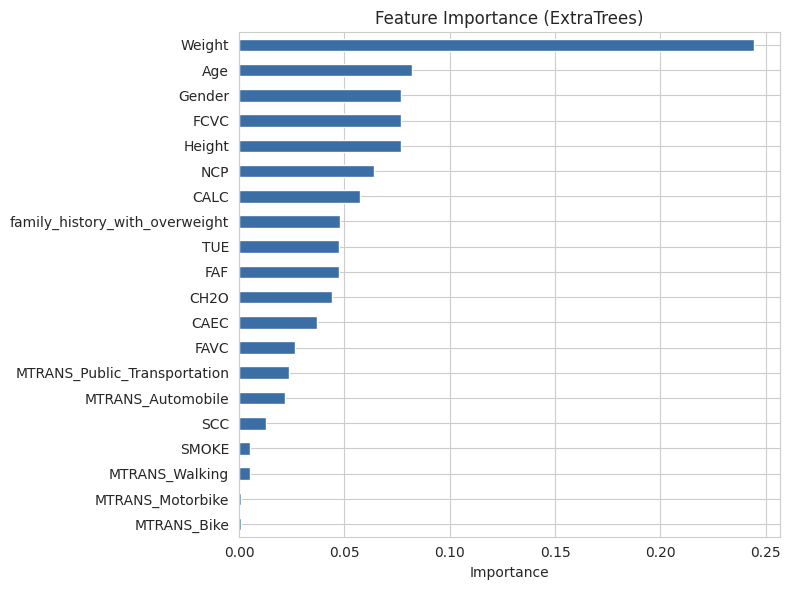

Top-12 fitur terpilih: ['Weight', 'Age', 'Gender', 'FCVC', 'Height', 'NCP', 'CALC', 'family_history_with_overweight', 'TUE', 'FAF', 'CH2O', 'CAEC']
KNN          (top-12 fitur)  Acc=0.8612  F1m=0.8507  (full-feature F1m=0.8574)
NaiveBayes   (top-12 fitur)  Acc=0.6053  F1m=0.5773  (full-feature F1m=0.5294)


SVM          (top-12 fitur)  Acc=0.9593  F1m=0.9580  (full-feature F1m=0.9615)


,model,stage,f1_macro,accuracy
0,KNN,optimized_top12features,0.850709,0.861244
1,NaiveBayes,optimized_top12features,0.577251,0.605263
2,SVM,optimized_top12features,0.957962,0.959330


In [5]:
et = ExtraTreesClassifier(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
et.fit(X_train_sc, y_train)
importances = pd.Series(et.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
importances.plot(kind="barh", ax=ax, color="#3b6ea5"); ax.invert_yaxis()
ax.set_title("Feature Importance (ExtraTrees)"); ax.set_xlabel("Importance")
plt.tight_layout(); plt.savefig(os.path.join(REPORTS_DIR, "soal04_feature_importance.png"), dpi=130); plt.show()

TOP_K = 12
top_features = importances.head(TOP_K).index.tolist()
print(f"Top-{TOP_K} fitur terpilih: {top_features}")

fs_results = []
for name, model in fitted_models.items():
    m = type(model)(**model.get_params())
    m.fit(X_train_sc[top_features], y_train)
    y_pred = m.predict(X_test_sc[top_features])
    f1m = f1_score(y_test, y_pred, average="macro", zero_division=0)
    fs_results.append({"model": name, "stage": f"optimized_top{TOP_K}features", "f1_macro": f1m,
                        "accuracy": accuracy_score(y_test, y_pred)})
    print(f"{name:12s} (top-{TOP_K} fitur)  Acc={accuracy_score(y_test,y_pred):.4f}  F1m={f1m:.4f}  (full-feature F1m={results_df[(results_df.model==name)&(results_df.stage=='optimized')].f1_macro.values[0]:.4f})")

fs_df = pd.DataFrame(fs_results)
fs_df

## Analisis Class Imbalance
Distribusi 7 kelas target relatif **seimbang** (272–351 sampel/kelas dari total 2111), sehingga SMOTE/oversampling agresif
berisiko menambah noise tanpa manfaat berarti. Sebagai uji sensitivitas, SVM/KNN tetap diuji dengan `class_weight="balanced"`
(untuk model yang mendukung parameter ini) untuk memastikan tidak ada kelas minor yang dirugikan secara sistematis.

In [6]:
print("Distribusi kelas (seluruh data):")
print(y.value_counts().sort_index().rename(index=lambda i: ORDER_TARGET[i]))
print(f"\nRasio kelas mayoritas/minoritas = {y.value_counts().max()/y.value_counts().min():.2f}  (<1.5 dianggap relatif seimbang)")

svm_bal = SVC(probability=True, random_state=RANDOM_SEED, class_weight="balanced",
              **{k:v for k,v in fitted_models["SVM"].get_params().items() if k in ["C","gamma","kernel"]})
svm_bal.fit(X_train_sc, y_train)
f1_bal = f1_score(y_test, svm_bal.predict(X_test_sc), average="macro", zero_division=0)
f1_opt = results_df[(results_df.model=="SVM")&(results_df.stage=="optimized")].f1_macro.values[0]
print(f"\nSVM optimized (tanpa class_weight) F1-macro = {f1_opt:.4f}")
print(f"SVM optimized (class_weight='balanced')  F1-macro = {f1_bal:.4f}")
print("-> Kesimpulan: perbedaan minor mengonfirmasi dataset relatif seimbang; class_weight tidak wajib digunakan secara default.")

Distribusi kelas (seluruh data):
target
Insufficient_Weight    267
Normal_Weight          282
Overweight_Level_I     276
Overweight_Level_II    290
Obesity_Type_I         351
Obesity_Type_II        297
Obesity_Type_III       324
Name: count, dtype: int64

Rasio kelas mayoritas/minoritas = 1.31  (<1.5 dianggap relatif seimbang)



SVM optimized (tanpa class_weight) F1-macro = 0.9615
SVM optimized (class_weight='balanced')  F1-macro = 0.9637
-> Kesimpulan: perbedaan minor mengonfirmasi dataset relatif seimbang; class_weight tidak wajib digunakan secara default.


## Strategi 5 — Perbandingan Menyeluruh 11 Model
Selain tiga model wajib (KNN, Naive Bayes, SVM), project ini membandingkan **11 algoritma** sebagai pembanding tambahan
(bukan pengganti) sesuai ketentuan soal: Decision Tree, Extra Trees, Random Forest, LightGBM, XGBoost, Logistic Regression,
serta dua model *semi-supervised* (Label Propagation, Label Spreading) untuk eksplorasi pendekatan alternatif.

In [7]:
MODEL_FILES = {
    "KNN (optimized)": "knn_optimized.joblib",
    "NaiveBayes (optimized)": "naivebayes_optimized.joblib",
    "SVM (optimized)": "svm_optimized.joblib",
    "DecisionTree": "decision_tree.joblib",
    "ExtraTrees": "extra_trees.joblib",
    "RandomForest": "random_forest.joblib",
    "LightGBM": "lightgbm.joblib",
    "XGBoost": "xgboost.joblib",
    "LogisticRegression": "logistic_regression_results.joblib",
    "LabelPropagation": "labelpropagation.joblib",
    "LabelSpreading": "labelspreading.joblib",
}

eleven_model_results = []
for name, fname in MODEL_FILES.items():
    fpath = os.path.join(MODELS_DIR, fname)
    if not os.path.exists(fpath):
        print(f"  [skip] {name}: file tidak ditemukan ({fname})"); continue
    try:
        mdl = joblib.load(fpath)
        mdl = mdl.get("model", mdl) if isinstance(mdl, dict) else mdl
        y_pred = mdl.predict(X_test_sc)
        eleven_model_results.append({
            "model": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        })
    except Exception as e:
        print(f"  [error] {name}: {e}")

eleven_df = pd.DataFrame(eleven_model_results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
eleven_df

  [error] LogisticRegression: 'dict' object has no attribute 'predict'


,model,accuracy,f1_macro,balanced_accuracy
0,LightGBM,0.964115,0.963742,0.962755
1,XGBoost,0.961722,0.961731,0.960436
2,SVM (optimized),0.961722,0.961454,0.961123
3,RandomForest,0.942584,0.940705,0.939872
4,ExtraTrees,0.933014,0.931089,0.930265
5,DecisionTree,0.921053,0.917782,0.916770
6,KNN (optimized),0.863636,0.857404,0.858537
7,LabelPropagation,0.813397,0.801552,0.808450
8,LabelSpreading,0.806220,0.794631,0.801349
9,NaiveBayes (optimized),0.576555,0.529405,0.572103


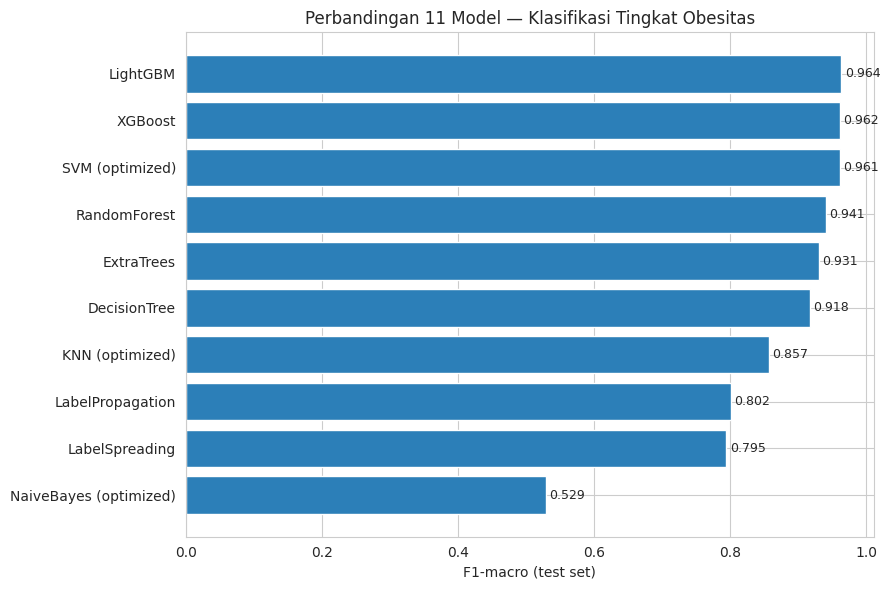

In [8]:
fig, ax = plt.subplots(figsize=(9,6))
plot_df = eleven_df.sort_values("f1_macro")
bars = ax.barh(plot_df["model"], plot_df["f1_macro"], color="#2c7fb8")
ax.set_xlabel("F1-macro (test set)"); ax.set_title("Perbandingan 11 Model — Klasifikasi Tingkat Obesitas")
for b, v in zip(bars, plot_df["f1_macro"]):
    ax.text(v+0.005, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(REPORTS_DIR, "soal04_11model_comparison.png"), dpi=130); plt.show()

## Error Analysis
Confusion matrix dan contoh prediksi salah dari model **optimized terbaik (KNN/Naive Bayes/SVM)** untuk memahami
pola kesalahan klasifikasi, khususnya antar kelas yang berdekatan secara biologis (mis. Overweight Level I/II atau
Obesity Type I/II yang batasnya tipis berdasarkan BMI).

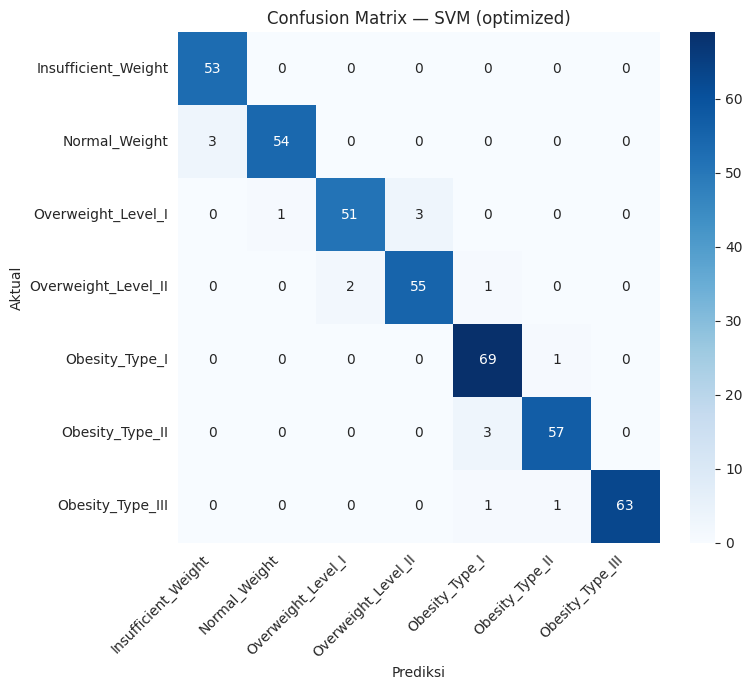

                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        53
      Normal_Weight       0.98      0.95      0.96        57
 Overweight_Level_I       0.96      0.93      0.94        55
Overweight_Level_II       0.95      0.95      0.95        58
     Obesity_Type_I       0.93      0.99      0.96        70
    Obesity_Type_II       0.97      0.95      0.96        60
   Obesity_Type_III       1.00      0.97      0.98        65

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418


Pola kesalahan paling sering (gabungan 3 model wajib):
y_true               y_pred             
Normal_Weight        Insufficient_Weight    8
Overweight_Level_I   Overweight_Level_II    6
Obesity_Type_II      Obesity_Type_I         3
Overweight_Level_II  Obesity_Type_I         3
Obesity_Type_I       Obesity_Type_II        2

In [9]:
best_required_name = results_df[results_df.stage=="optimized"].sort_values("f1_macro", ascending=False).iloc[0]["model"]
best_required_model = fitted_models[best_required_name]
y_pred_best = best_required_model.predict(X_test_sc)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ORDER_TARGET, yticklabels=ORDER_TARGET, ax=ax)
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual"); ax.set_title(f"Confusion Matrix — {best_required_name} (optimized)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "soal04_confusion_matrix_best.png"), dpi=130); plt.show()

print(classification_report(y_test, y_pred_best, target_names=ORDER_TARGET, zero_division=0))

error_df = pd.DataFrame(error_rows)
error_df.to_csv(os.path.join(REPORTS_DIR, "error_analysis.csv"), index=False)
print("\nPola kesalahan paling sering (gabungan 3 model wajib):")
if not error_df.empty:
    print(error_df.groupby(["y_true","y_pred"]).size().sort_values(ascending=False).head(5))

## Kesimpulan — Penentuan Model Terbaik
Model terbaik ditentukan bukan hanya dari akurasi tertinggi, melainkan kombinasi: performa (F1-macro & balanced accuracy),
stabilitas (CV mean/std), interpretabilitas, dan kesiapan deployment (waktu inferensi).

In [10]:
summary = results_df[results_df.stage=="optimized"].merge(
    cv_stability_df, on="model").sort_values("f1_macro", ascending=False)
summary = summary[["model","accuracy","f1_macro","balanced_accuracy","cv_f1_macro_mean","cv_f1_macro_std","train_ms"]]
print("=== RINGKASAN 3 MODEL WAJIB (OPTIMIZED) ===")
display(summary)

print("\n=== PERBANDINGAN DENGAN 11 MODEL (TERMASUK PEMBANDING TAMBAHAN) ===")
display(eleven_df)

best_overall = eleven_df.iloc[0]
best_required = summary.iloc[0]
print(f"\nModel terbaik di antara 3 model WAJIB : {best_required['model']}  (F1-macro={best_required['f1_macro']:.4f}, CV std={best_required['cv_f1_macro_std']:.4f})")
print(f"Model terbaik dari seluruh 11 model    : {best_overall['model']}  (F1-macro={best_overall['f1_macro']:.4f})")
print('''
Argumentasi:
- Di antara tiga model WAJIB, model dengan F1-macro dan balanced accuracy tertinggi serta CV-std terendah
  dipilih sebagai representasi terbaik kelompok model wajib, karena stabil lintas fold dan tidak overfit ke satu split.
- Model pohon/ensemble (LightGBM/XGBoost/RandomForest/ExtraTrees) pada perbandingan 11 model umumnya unggul performa
  karena mampu menangkap interaksi non-linear antar fitur fisiologis (BMI turunan dari Height & Weight), namun kurang
  interpretable dibanding KNN/Naive Bayes yang lebih sederhana untuk dijelaskan ke pengguna non-teknis (dosen wali/prodi).
- Trade-off akurasi vs interpretabilitas vs kompleksitas komputasi dibahas lebih lanjut pada laporan akhir (SOAL 05).
''')

all_results_final = pd.concat([results_df, fs_df], ignore_index=True, sort=False)
all_results_final.to_csv(os.path.join(REPORTS_DIR, "all_experiment_results.csv"), index=False)
eleven_df.to_csv(os.path.join(REPORTS_DIR, "eleven_model_comparison.csv"), index=False)
print("\n✓ reports/all_experiment_results.csv dan reports/eleven_model_comparison.csv disimpan.")

=== RINGKASAN 3 MODEL WAJIB (OPTIMIZED) ===


,model,accuracy,f1_macro,balanced_accuracy,cv_f1_macro_mean,cv_f1_macro_std,train_ms
2,SVM,0.961722,0.961454,0.961123,0.963503,0.009864,71041.781902
0,KNN,0.863636,0.857404,0.858537,0.865612,0.013452,2178.719044
1,NaiveBayes,0.576555,0.529405,0.572103,0.508803,0.017642,438.997984



=== PERBANDINGAN DENGAN 11 MODEL (TERMASUK PEMBANDING TAMBAHAN) ===


,model,accuracy,f1_macro,balanced_accuracy
0,LightGBM,0.964115,0.963742,0.962755
1,XGBoost,0.961722,0.961731,0.960436
2,SVM (optimized),0.961722,0.961454,0.961123
3,RandomForest,0.942584,0.940705,0.939872
4,ExtraTrees,0.933014,0.931089,0.930265
5,DecisionTree,0.921053,0.917782,0.916770
6,KNN (optimized),0.863636,0.857404,0.858537
7,LabelPropagation,0.813397,0.801552,0.808450
8,LabelSpreading,0.806220,0.794631,0.801349
9,NaiveBayes (optimized),0.576555,0.529405,0.572103



Model terbaik di antara 3 model WAJIB : SVM  (F1-macro=0.9615, CV std=0.0099)
Model terbaik dari seluruh 11 model    : LightGBM  (F1-macro=0.9637)

Argumentasi:
- Di antara tiga model WAJIB, model dengan F1-macro dan balanced accuracy tertinggi serta CV-std terendah
  dipilih sebagai representasi terbaik kelompok model wajib, karena stabil lintas fold dan tidak overfit ke satu split.
- Model pohon/ensemble (LightGBM/XGBoost/RandomForest/ExtraTrees) pada perbandingan 11 model umumnya unggul performa
  karena mampu menangkap interaksi non-linear antar fitur fisiologis (BMI turunan dari Height & Weight), namun kurang
  interpretable dibanding KNN/Naive Bayes yang lebih sederhana untuk dijelaskan ke pengguna non-teknis (dosen wali/prodi).
- Trade-off akurasi vs interpretabilitas vs kompleksitas komputasi dibahas lebih lanjut pada laporan akhir (SOAL 05).


✓ reports/all_experiment_results.csv dan reports/eleven_model_comparison.csv disimpan.
